# Create positions from tissue boundary

In [1]:
import os
import sys
from pathlib import Path
import csv
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MERCI_DIR  = Path(os.getcwd()).parent          # MERci/ (notebook lives in MERci/notebooks/)
SAMPLE_DIR = MERCI_DIR.parent                  # experiment root, e.g. LT048_sample_18/
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.io             import save_positions_array
from MERci.acquisition.positions import (
    create_grid_positions, generate_scanning_path,
    load_hole_polygons, filter_scanning_path,
    close_scanning_path, get_path_stats,
)

In [2]:
POSITIONS_DIR = SAMPLE_DIR / "positions"
POSITIONS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_NAME = SAMPLE_DIR.name

pixel_size_um        = 0.109
image_size_px        = 2048
non_overlap_fraction = 0.9

step_size_um = pixel_size_um * image_size_px * non_overlap_fraction
fov_size_um  = pixel_size_um * image_size_px

print(f"SAMPLE_DIR    : {SAMPLE_DIR}")
print(f"SAMPLE_NAME   : {SAMPLE_NAME}")
print(f"POSITIONS_DIR : {POSITIONS_DIR}")
print(f"Step size     : {step_size_um:.1f} um")
print(f"FOV size      : {fov_size_um:.1f} um")

SAMPLE_DIR    : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time
SAMPLE_NAME   : 251225_LT027_saving_time
POSITIONS_DIR : c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\positions
Step size     : 200.9 um
FOV size      : 223.2 um


Boundary bounds: x=[-5259, 2592]  y=[-3554, 1214]
Bounding box centre (grid centre): (-1333.2, -1170.2)


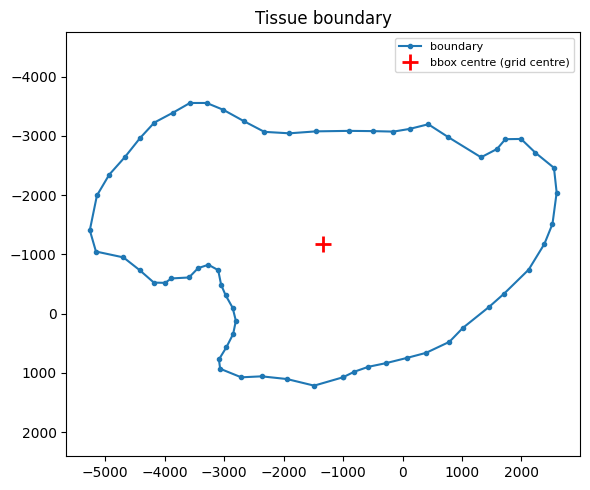

In [3]:
with open(POSITIONS_DIR / "boundary_positions.txt") as fh:
    boundary_pts = [(float(r[0]), float(r[1])) for r in csv.reader(fh)]

boundary = Polygon(boundary_pts)
xmin, ymin, xmax, ymax = boundary.bounds
cx_bbox = (xmin + xmax) / 2
cy_bbox = (ymin + ymax) / 2
print(f"Boundary bounds: x=[{xmin:.0f}, {xmax:.0f}]  y=[{ymin:.0f}, {ymax:.0f}]")
print(f"Bounding box centre (grid centre): ({cx_bbox:.1f}, {cy_bbox:.1f})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(*boundary.exterior.xy, ".-", label="boundary")
ax.plot(cx_bbox, cy_bbox, "r+", ms=12, mew=2, label="bbox centre (grid centre)")
ax.invert_yaxis(); ax.axis("equal")
ax.legend(fontsize=8); plt.title("Tissue boundary"); plt.tight_layout()
fig.savefig(POSITIONS_DIR / f"boundary_{SAMPLE_NAME}.png", dpi=150)
plt.show()

Full grid: 25 rows x 41 cols = 1025 FOVs (both odd)
Loaded 5 hole polygon(s)
After overlap filter: 647 FOVs kept


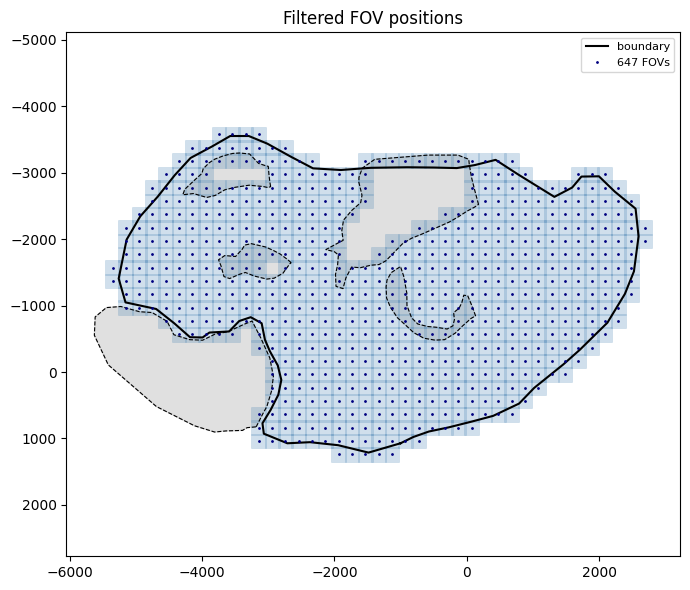

In [4]:
grid, xs, ys = create_grid_positions(boundary, step_size_um)
print(f"Full grid: {len(ys)} rows x {len(xs)} cols = {grid.size // 2} FOVs (both odd)")

path  = generate_scanning_path(grid, direction="vertical")
holes = load_hole_polygons(POSITIONS_DIR)
print(f"Loaded {len(holes)} hole polygon(s)")

filtered = filter_scanning_path(path, boundary, holes, fov_size_um)
print(f"After overlap filter: {len(filtered)} FOVs kept")

half = fov_size_um / 2
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(*boundary.exterior.xy, "k-", lw=1.5, label="boundary")
for hole in holes:
    ax.fill(*hole.exterior.xy, color="0.8", alpha=0.6)
    ax.plot(*hole.exterior.xy, "k--", lw=0.8)
for x, y in filtered:
    rect = mpatches.Rectangle((x - half, y - half), fov_size_um, fov_size_um,
                               lw=0.4, edgecolor="steelblue", facecolor="steelblue", alpha=0.25)
    ax.add_patch(rect)
ax.plot(filtered[:, 0], filtered[:, 1], ".", ms=2, color="navy", label=f"{len(filtered)} FOVs")
ax.invert_yaxis(); ax.axis("equal")
ax.legend(fontsize=8); plt.title("Filtered FOV positions"); plt.tight_layout()
fig.savefig(POSITIONS_DIR / f"fov_positions_{SAMPLE_NAME}.png", dpi=150)
plt.show()

647 FOVs  |  path 145.1 mm  |  max step 1819 um


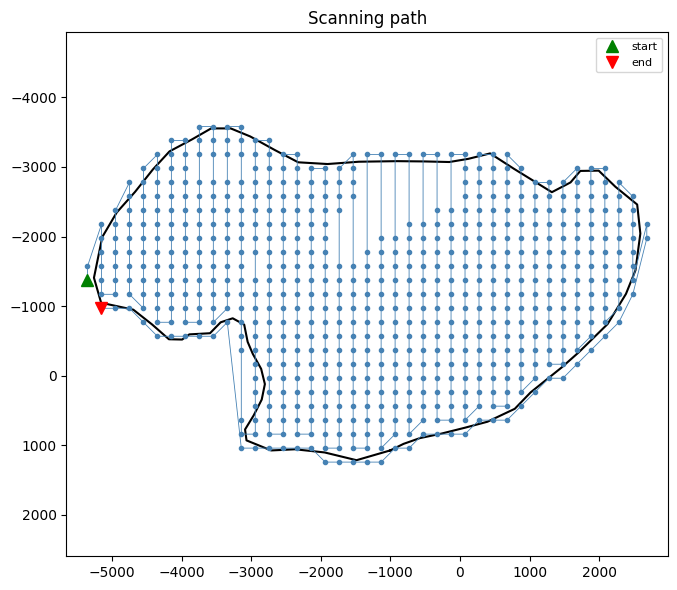

In [5]:
reordered, _ = close_scanning_path(filtered, step_size_um, return_side="top")

total_um, max_step_um = get_path_stats(reordered)
print(f"{reordered.shape[0]} FOVs  |  path {total_um/1000:.1f} mm  |  max step {max_step_um:.0f} um")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(*boundary.exterior.xy, "k-", lw=1.5)
ax.plot(reordered[:, 0], reordered[:, 1], "-o", ms=3, lw=0.6, color="steelblue")
ax.plot(*reordered[0],  "g^", ms=8, label="start")
ax.plot(*reordered[-1], "rv", ms=8, label="end")
ax.invert_yaxis(); ax.axis("equal")
ax.legend(fontsize=8); plt.title("Scanning path"); plt.tight_layout()
fig.savefig(POSITIONS_DIR / f"scanning_path_{SAMPLE_NAME}.png", dpi=150)
plt.show()

In [6]:
out_path = POSITIONS_DIR / f"positions_{SAMPLE_NAME}.txt"
save_positions_array(reordered, out_path)
print(f"Written: {out_path}")

Written: c:\Users\Leonardo\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\positions\positions_251225_LT027_saving_time.txt
